# Hard-congestion variational mean field game

**Credit.** This notebook is part of *Optimal Transport for Machine Learners* by [Gabriel Peyré](https://www.gpeyre.com/), CNRS and École normale supérieure, PSL University. The book and reproducible sources are available at [github.com/gpeyre/ot4ml](https://github.com/gpeyre/ot4ml).

**Copyright.** Copyright (c) 2025 Gabriel Peyré. Released under the MIT License; see the repository `LICENSE` file.

This notebook generates `fig:dynamic-variational-mfg-hard-congestion`. It adapts the two-room variational-MFG experiment of Benamou, Carlier, and Santambrogio. The initial density is one uniform disk in the left room, while the endpoint is its mirrored disk in the right room. For a global density cap $\kappa$, the convex planning problem is
$$
\min_{\rho,m}
\int_0^1\!\int_\Omega \frac{|m_t(x)|^2}{2\rho_t(x)}\,dx\,dt
+\int_0^1\!\iota_{\{0\leq\rho_t(x)\leq\kappa\}}\,dt,
\qquad
\partial_t\rho_t+\operatorname{div}m_t=0,
\quad \rho_{t=0}=\rho_0,\quad\rho_{t=1}=\rho_\star.
$$
We compare the unconstrained Benamou--Brenier path with the tight feasible cap $\kappa=\|\rho_0\|_\infty$. The finite cap equals the constant density on the initial disk, so the crowd cannot compress above its initial packing density while crossing the one-cell doorway.

In [1]:
# --- OT4ML lightweight Colab bootstrap: one shared core, no repository clone.
from pathlib import Path as _OT4ML_Path
import importlib.util as _OT4ML_importlib_util
import os as _OT4ML_os
import sys as _OT4ML_sys
import urllib.request as _OT4ML_urllib_request

_OT4ML_MPLCONFIG = _OT4ML_Path(
    _OT4ML_os.environ.get(
        "MPLCONFIGDIR",
        _OT4ML_Path(_OT4ML_os.environ.get("TMPDIR", "/tmp")) / "mpl-ot4ml",
    )
)
_OT4ML_MPLCONFIG.mkdir(parents=True, exist_ok=True)
_OT4ML_os.environ["MPLCONFIGDIR"] = str(_OT4ML_MPLCONFIG)


def _ot4ml_find_core():
    """Locate the single shared figure core in a local checkout."""
    here = _OT4ML_Path.cwd().resolve()
    for base in (here, *here.parents):
        for candidate in (base / "notebooks-figures" / "figure_style.py", base / "figure_style.py"):
            if candidate.exists():
                return candidate
    return None


def _ot4ml_download_core(target):
    """Download only the shared figure core, never the full repository."""
    target.parent.mkdir(parents=True, exist_ok=True)
    urls = (
        "https://raw.githubusercontent.com/gpeyre/ot4ml/main/notebooks-figures/figure_style.py",
        "https://www.gpeyre.com/ot4ml/notebooks-figures/figure_style.py",
    )
    errors = []
    for url in urls:
        try:
            with _OT4ML_urllib_request.urlopen(url, timeout=30) as response:
                target.write_bytes(response.read())
            return target
        except Exception as error:
            errors.append(f"{url}: {error}")
    raise RuntimeError("Unable to download the OT4ML figure core.\n" + "\n".join(errors))


_OT4ML_CORE = _ot4ml_find_core()
if _OT4ML_CORE is None:
    _OT4ML_CORE = _ot4ml_download_core(
        _OT4ML_Path("/content/ot4ml-figure-runtime/notebooks-figures/figure_style.py")
    )

_OT4ML_SPEC = _OT4ML_importlib_util.spec_from_file_location("figure_style", _OT4ML_CORE)
if _OT4ML_SPEC is None or _OT4ML_SPEC.loader is None:
    raise RuntimeError(f"Cannot load OT4ML figure core from {_OT4ML_CORE}")
_OT4ML_STYLE = _OT4ML_importlib_util.module_from_spec(_OT4ML_SPEC)
_OT4ML_sys.modules["figure_style"] = _OT4ML_STYLE
_OT4ML_SPEC.loader.exec_module(_OT4ML_STYLE)

_OT4ML_PACKAGES = (
    ('numpy', 'numpy'),
    ('matplotlib', 'matplotlib'),
    ('IPython', 'ipython'),
    ('scipy', 'scipy'),
)
_OT4ML_REQUIRED_FILES = (

)
ROOT = _OT4ML_STYLE.configure_notebook(
    packages=_OT4ML_PACKAGES,
    required_files=_OT4ML_REQUIRED_FILES,
)
FIGROOT = ROOT / "notebooks-figures"
NOTEBOOK_DIR = FIGROOT

In [2]:
from dataclasses import dataclass
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
from matplotlib.animation import PillowWriter
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from IPython.display import Image, display

from figure_style import (
    BLUE,
    GRAY,
    RED,
    figure_dir,
    interp_color,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()

NAME = "dynamic-variational-mfg-hard-congestion"
OUT = figure_dir(NAME)
THUMB = ROOT / "notebooks-figures" / "thumbnails" / f"{NAME}.png"
THUMB.parent.mkdir(parents=True, exist_ok=True)

## Geometry and endpoint preference

The computational box contains two rectangular rooms connected through a narrow door resolved by several grid cells. Zero density is imposed outside this nonconvex domain. The initial and preferred terminal laws are uniform on two mirrored disks. The finite capacity $\kappa=\|\rho_0\|_\infty$ is therefore feasible at both endpoints but becomes active at the bottleneck: the unconstrained crowd can concentrate while crossing, whereas the capped crowd must queue and spread.

In [3]:
@dataclass(frozen=True)
class Grid:
    """Uniform space-time grid used by the finite-volume discretization."""

    nx: int = 48
    ny: int = 31
    nt: int = 8
    xmin: float = -3.2
    xmax: float = 3.2
    ymin: float = -1.8
    ymax: float = 1.8

    @property
    def hx(self):
        """Horizontal grid spacing."""
        return (self.xmax - self.xmin) / self.nx

    @property
    def hy(self):
        """Vertical grid spacing."""
        return (self.ymax - self.ymin) / self.ny

    @property
    def dt(self):
        """Time step."""
        return 1.0 / self.nt


grid = Grid()
x = np.linspace(grid.xmin + grid.hx / 2, grid.xmax - grid.hx / 2, grid.nx)
y = np.linspace(grid.ymin + grid.hy / 2, grid.ymax - grid.hy / 2, grid.ny)
X, Y = np.meshgrid(x, y, indexing="xy")

ROOM = (
    ((X > -3.05) & (X < -0.24) & (np.abs(Y) < 1.48))
    | ((X > 0.24) & (X < 3.05) & (np.abs(Y) < 1.48))
    | ((np.abs(X) <= 0.34) & (np.abs(Y) < 0.07))
)

In [4]:
def normalize_density(values):
    """Restrict an array to the rooms and normalize its spatial integral.

    Args:
        values: Nonnegative values sampled at cell centers.

    Returns:
        Array of shape ``(ny, nx)`` with unit discrete spatial integral.
    """
    density = np.maximum(values, 0.0) * ROOM
    mass = density.sum() * grid.hx * grid.hy
    if mass <= 0:
        raise ValueError("The prescribed support has zero mass on the grid.")
    return density / mass


def disk_density(center, radius):
    """Return the uniform probability density on one disk.

    Args:
        center: ``(x, y)`` center of the disk.
        radius: Positive disk radius.

    Returns:
        Normalized cell-centered density supported on the disk.
    """
    if radius <= 0:
        raise ValueError("The disk radius must be positive.")
    center_x, center_y = center
    support = (X - center_x) ** 2 + (Y - center_y) ** 2 <= radius**2
    return normalize_density(support.astype(float))


DISK_RADIUS = 0.88
INITIAL_CENTER = (-1.645, 0.00)
TARGET_CENTER = (1.645, 0.00)
rho_initial = disk_density(INITIAL_CENTER, DISK_RADIUS)
rho_target = disk_density(TARGET_CENTER, DISK_RADIUS)

INITIAL_PEAK = float(rho_initial.max())
CAPS = (np.inf, INITIAL_PEAK)
CAP_LABELS = (
    "no cap",
    r"$\kappa=\|\rho_0\|_\infty$",
)

print(f"initial mass: {rho_initial.sum() * grid.hx * grid.hy:.12f}")
print(f"initial peak: {rho_initial.max():.6f}")
print(f"target peak:  {rho_target.max():.6f}")
print(f"finite cap:   {CAPS[1]:.6f}")
assert np.isclose(rho_initial.max(), rho_target.max(), rtol=0.0, atol=1.0e-12)
assert rho_target.max() <= CAPS[1] + 1.0e-12

initial mass: 1.000000000000
initial peak: 0.434028
target peak:  0.434028
finite cap:   0.434028


## Affine continuity constraint

We use cell-centered density and momentum variables. Backward differences discretize the divergence, and the zero-density exterior of the two-room domain enforces impermeable walls. The linear system
$$
A(\rho,m)=b
$$
contains every discrete continuity equation and the initial condition. Its Euclidean projection is computed repeatedly, so the sparse factorization of $AA^\top$ is cached once.

In [5]:
def periodic_backward_difference(size, spacing):
    """Return the periodic backward-difference matrix on a one-dimensional grid."""
    rows = np.arange(size)
    previous = (rows - 1) % size
    data = np.concatenate([np.ones(size), -np.ones(size)])
    row_ids = np.concatenate([rows, rows])
    col_ids = np.concatenate([rows, previous])
    return sp.coo_matrix(
        (data, (row_ids, col_ids)), shape=(size, size)
    ).tocsr() / spacing


def build_constraint_projector(grid, initial_density, terminal_density):
    """Build the affine continuity operator and its orthogonal projector.

    Args:
        grid: Space-time discretization.
        initial_density: Prescribed density at time zero.
        terminal_density: Prescribed density at time one.

    Returns:
        Tuple ``(A, b, project)``. The callable ``project(z)`` returns the
        Euclidean projection of a packed density-momentum vector onto
        ``{z: A z = b}``.
    """
    n_space = grid.nx * grid.ny
    dx = sp.kron(
        sp.eye(grid.ny, format="csr"),
        periodic_backward_difference(grid.nx, grid.hx),
        format="csr",
    )
    dy = sp.kron(
        periodic_backward_difference(grid.ny, grid.hy),
        sp.eye(grid.nx, format="csr"),
        format="csr",
    )
    time_difference = sp.diags(
        [-np.ones(grid.nt), np.ones(grid.nt)],
        [0, 1],
        shape=(grid.nt, grid.nt + 1),
        format="csr",
    )
    identity_space = sp.eye(n_space, format="csr")
    identity_time = sp.eye(grid.nt, format="csr")

    density_block = sp.kron(time_difference, identity_space, format="csr")
    flux_x_block = grid.dt * sp.kron(identity_time, dx, format="csr")
    flux_y_block = grid.dt * sp.kron(identity_time, dy, format="csr")
    continuity = sp.hstack(
        [density_block, flux_x_block, flux_y_block], format="csr"
    )

    n_density = (grid.nt + 1) * n_space
    n_momentum = grid.nt * n_space
    initial_selector = sp.hstack(
        [
            identity_space,
            sp.csr_matrix((n_space, n_density - n_space)),
            sp.csr_matrix((n_space, 2 * n_momentum)),
        ],
        format="csr",
    )
    terminal_selector = sp.hstack(
        [
            sp.csr_matrix((n_space, n_density - n_space)),
            identity_space,
            sp.csr_matrix((n_space, 2 * n_momentum)),
        ],
        format="csr",
    )
    operator = sp.vstack(
        [continuity, initial_selector, terminal_selector], format="csc"
    )
    right_hand_side = np.concatenate(
        [
            np.zeros(grid.nt * n_space),
            initial_density.ravel(),
            terminal_density.ravel(),
        ]
    )

    factor = spla.splu((operator @ operator.T).tocsc())
    transpose = operator.T.tocsr()

    def project(vector):
        """Project one packed vector onto the affine continuity constraint."""
        residual = operator @ vector - right_hand_side
        return vector - transpose @ factor.solve(residual)

    return operator, right_hand_side, project


A, b, project_affine = build_constraint_projector(
    grid, rho_initial, rho_target
)
print(f"constraint matrix: {A.shape[0]} x {A.shape[1]}")

constraint matrix: 16320 x 47040


## Local proximal map

For the quadratic perspective
$$
J(r,m)=\frac{|m|^2}{2r},
$$
the proximal update is pointwise. For fixed updated density $r$, minimization in the momentum gives
$$
m=\frac{r}{r+\gamma}m_0.
$$
The remaining scalar minimization has a strictly increasing derivative and is solved by vectorized Newton iterations before clipping to $[0,\kappa]$. The terminal update is the closed-form proximal map of the quadratic target penalty.

In [6]:
N_SPACE = grid.nx * grid.ny
N_DENSITY = (grid.nt + 1) * N_SPACE
N_MOMENTUM = grid.nt * N_SPACE
N_VARIABLES = N_DENSITY + 2 * N_MOMENTUM


def pack_fields(density, momentum_x, momentum_y):
    """Pack density and two momentum components into one vector."""
    return np.concatenate(
        [density.ravel(), momentum_x.ravel(), momentum_y.ravel()]
    )


def unpack_fields(vector):
    """Unpack one optimization vector into density and momentum arrays."""
    density = vector[:N_DENSITY].reshape(
        grid.nt + 1, grid.ny, grid.nx
    )
    momentum_x = vector[N_DENSITY:N_DENSITY + N_MOMENTUM].reshape(
        grid.nt, grid.ny, grid.nx
    )
    momentum_y = vector[N_DENSITY + N_MOMENTUM:].reshape(
        grid.nt, grid.ny, grid.nx
    )
    return density, momentum_x, momentum_y


def cap_array(kappa):
    """Return a global cap on the rooms and zero capacity outside."""
    interior_cap = np.inf if np.isinf(kappa) else float(kappa)
    return np.where(ROOM, interior_cap, 0.0)

In [7]:
def prox_action_cap(vector, gamma, cap):
    """Evaluate the proximal map of the kinetic action and hard cap.

    Args:
        vector: Packed density-momentum iterate.
        gamma: Douglas--Rachford proximal parameter.
        cap: Spatial array containing the density upper bound.

    Returns:
        Packed proximal point with nonnegative capped densities.
    """
    density_0, momentum_x_0, momentum_y_0 = unpack_fields(vector)
    density = np.empty_like(density_0)
    speed_squared = momentum_x_0**2 + momentum_y_0**2

    interior_density = np.maximum(density_0[:-1], 0.0)
    for _ in range(28):
        derivative = (
            interior_density
            - density_0[:-1]
            - 0.5 * gamma * speed_squared / (interior_density + gamma) ** 2
        )
        hessian = (
            1
            + gamma * speed_squared / (interior_density + gamma) ** 3
        )
        interior_density = np.maximum(
            interior_density - derivative / hessian, 0.0
        )
    interior_density = np.minimum(interior_density, cap[None, :, :])
    density[:-1] = interior_density

    momentum_scale = interior_density / (interior_density + gamma)
    momentum_x = momentum_scale * momentum_x_0
    momentum_y = momentum_scale * momentum_y_0

    # Endpoint values are imposed by the affine projector; the cap still
    # applies to the terminal density in this local proximal step.
    density[-1] = np.clip(density_0[-1], 0.0, cap)
    return pack_fields(density, momentum_x, momentum_y)

## Douglas--Rachford optimization and feasibility certificate

The kinetic action and density cap are local convex terms, while continuity and both hard endpoints are affine constraints. Douglas--Rachford splitting alternates the cached affine projection with the local proximal map. This is the proximal interpretation of the ALG2 strategy used for Benamou--Brenier transport and variational MFGs.

A finite splitting iterate has a small but nonzero feasibility error. The solver therefore applies Dykstra's algorithm to the Douglas--Rachford shadow, projecting onto the intersection of the affine continuity/end-point constraints and the global box $0\leq\rho_t\leq\kappa$. The notebook accepts a solution only if the splitting, continuity, mass, cap, positivity, and exterior-domain residuals all pass explicit numerical tests. Thus the cap is enforced throughout optimization and certified over every spatial cell and time slab; it is not applied afterward to the displayed snapshots.

In [8]:
def solve_variational_mfg(
    kappa,
    *,
    initial_guess=None,
    initial_iterate=None,
    max_iterations=20000,
    gamma=0.28,
    relaxation=1.65,
    fixed_point_tolerance=8.0e-5,
    check_every=100,
    polish_tolerance=1.0e-8,
    mass_tolerance=5.0e-7,
    polish_iterations=4000,
):
    """Solve one hard-congestion variational MFG problem.

    Douglas--Rachford first solves the convex objective splitting. A final
    Dykstra projection onto the affine continuity/end-point set and the density box
    removes the small feasibility error of the finite DR iterate.

    Args:
        kappa: Global density cap; use ``np.inf`` for no cap.
        initial_guess: Optional previous density-momentum path used to warm-start.
        initial_iterate: Optional raw Douglas--Rachford iterate for an exact
            resumable continuation.
        max_iterations: Maximum Douglas--Rachford iterations.
        gamma: Proximal parameter.
        relaxation: Relaxation in ``(0, 2)``.
        fixed_point_tolerance: RMS tolerance for the splitting residual.
        check_every: Frequency of Douglas--Rachford diagnostics.
        polish_tolerance: RMS continuity tolerance after Dykstra projection.
        mass_tolerance: Maximum relative mass error after projection.
        polish_iterations: Maximum Dykstra feasibility iterations.

    Returns:
        Dictionary containing density, momentum, cap, and diagnostics.
    """
    cap = cap_array(kappa)
    if initial_iterate is not None:
        if initial_iterate.shape != (N_VARIABLES,):
            raise ValueError("initial_iterate has an incompatible shape")
        iterate = np.asarray(initial_iterate, dtype=float).copy()
    elif initial_guess is None:
        times = np.linspace(0.0, 1.0, grid.nt + 1)[:, None, None]
        initial_path = (1.0 - times) * rho_initial + times * rho_target
        iterate = pack_fields(
            initial_path,
            np.zeros((grid.nt, grid.ny, grid.nx)),
            np.zeros((grid.nt, grid.ny, grid.nx)),
        )
    else:
        iterate = pack_fields(
            initial_guess["density"],
            initial_guess["momentum_x"],
            initial_guess["momentum_y"],
        )
    history = []

    def project_box(vector):
        """Project densities onto the global cap while leaving momenta fixed."""
        density, momentum_x, momentum_y = unpack_fields(vector)
        density = np.clip(density, 0.0, cap[None, :, :])
        return pack_fields(density, momentum_x, momentum_y)

    def box_residuals(density):
        """Return cap, exterior, and negativity residuals for one path."""
        if np.isinf(kappa):
            cap_violation = 0.0
        else:
            cap_violation = max(
                0.0, float(np.max(density[:, ROOM] - kappa))
            )
        exterior_leakage = max(
            0.0, float(np.max(density[:, ~ROOM]))
        )
        negative_part = max(0.0, float(-np.min(density)))
        return cap_violation, exterior_leakage, negative_part

    dr_converged = False
    for iteration in range(max_iterations):
        feasible = project_affine(iterate)
        proximal = prox_action_cap(
            2 * feasible - iterate, gamma, cap
        )
        mismatch = np.linalg.norm(proximal - feasible) / np.sqrt(N_VARIABLES)
        iterate += relaxation * (proximal - feasible)

        should_check = (
            iteration % check_every == 0
            or iteration == max_iterations - 1
        )
        if should_check:
            history.append((iteration, mismatch))
            dr_converged = (
                iteration >= 1000 and mismatch < fixed_point_tolerance
            )
            if dr_converged:
                break

    # Dykstra's algorithm projects the DR shadow onto the affine continuity
    # and endpoint constraints intersected with the global density box. The
    # returned iterate is the
    # box projection, so the cap and positivity hold up to roundoff.
    dr_shadow = project_affine(iterate)
    polished = dr_shadow.copy()
    affine_correction = np.zeros_like(polished)
    box_correction = np.zeros_like(polished)
    polish_converged = False
    for polish_iteration in range(polish_iterations):
        affine_input = polished + affine_correction
        affine_point = project_affine(affine_input)
        affine_correction = affine_input - affine_point

        box_input = affine_point + box_correction
        polished = project_box(box_input)
        box_correction = box_input - polished

        if polish_iteration % 20 == 0 or polish_iteration == polish_iterations - 1:
            continuity_residual = float(
                np.linalg.norm(A @ polished - b) / np.sqrt(len(b))
            )
            polished_density, _, _ = unpack_fields(polished)
            mass_error = float(
                np.max(
                    np.abs(
                        polished_density.sum(axis=(1, 2))
                        * grid.hx * grid.hy - 1.0
                    )
                )
            )
            if (
                continuity_residual < polish_tolerance
                and mass_error < mass_tolerance
            ):
                polish_converged = True
                break

    density, momentum_x, momentum_y = unpack_fields(polished)
    cap_violation, exterior_leakage, negative_part = box_residuals(density)
    mass_path = density.sum(axis=(1, 2)) * grid.hx * grid.hy
    if np.isfinite(kappa):
        interior_density = density[:, ROOM]
        saturation_fraction = float(
            np.mean(interior_density >= 0.99 * float(kappa))
        )
    else:
        saturation_fraction = 0.0
    diagnostics = {
        "iterations": iteration + 1,
        "dr_converged": dr_converged,
        "fixed_point_residual": float(mismatch),
        "polish_iterations": polish_iteration + 1,
        "polish_converged": polish_converged,
        "polish_displacement": float(
            np.linalg.norm(polished - dr_shadow) / np.sqrt(N_VARIABLES)
        ),
        "continuity_residual": float(
            np.linalg.norm(A @ polished - b) / np.sqrt(len(b))
        ),
        "cap_violation": cap_violation,
        "exterior_leakage": exterior_leakage,
        "negative_part": negative_part,
        "mass_error": float(np.max(np.abs(mass_path - 1.0))),
        "mass_min": float(np.min(mass_path)),
        "mass_max": float(np.max(mass_path)),
        "initial_error": float(np.max(np.abs(density[0] - rho_initial))),
        "terminal_error": float(np.max(np.abs(density[-1] - rho_target))),
        "saturation_fraction": saturation_fraction,
    }
    return {
        "kappa": kappa,
        "cap": cap,
        "dr_iterate": iterate,
        "density": density,
        "momentum_x": momentum_x,
        "momentum_y": momentum_y,
        "history": np.asarray(history),
        "diagnostics": diagnostics,
    }

In [9]:
solutions = []
for index, kappa in enumerate(CAPS):
    warm_start = None if index == 0 else solutions[0]
    result = solve_variational_mfg(kappa, initial_guess=warm_start)
    solutions.append(result)
    label = "+infinity" if np.isinf(kappa) else f"{kappa:.6f}"
    diagnostics = result["diagnostics"]
    print(
        f"kappa={label}: residual={diagnostics['fixed_point_residual']:.2e}, "
        f"continuity={diagnostics['continuity_residual']:.2e}, "
        f"mass in [{diagnostics['mass_min']:.9f}, "
        f"{diagnostics['mass_max']:.9f}], "
        f"saturation={diagnostics['saturation_fraction']:.2%}"
    )

for result in solutions:
    diagnostics = result["diagnostics"]
    assert diagnostics["dr_converged"], diagnostics
    assert diagnostics["polish_converged"], diagnostics
    assert diagnostics["fixed_point_residual"] < 8.0e-5
    assert diagnostics["continuity_residual"] < 1.0e-8
    assert diagnostics["mass_error"] < 5.0e-7
    assert diagnostics["initial_error"] < 1.0e-8
    assert diagnostics["terminal_error"] < 1.0e-8
    assert diagnostics["cap_violation"] <= 1.0e-12
    assert diagnostics["exterior_leakage"] <= 1.0e-12
    assert diagnostics["negative_part"] <= 1.0e-12

kappa=+infinity: {'iterations': 11401, 'dr_converged': np.True_, 'fixed_point_residual': 7.960766937097785e-05, 'polish_iterations': 2841, 'polish_converged': True, 'polish_displacement': 4.813744404273372e-05, 'continuity_residual': 9.939193613264952e-09, 'cap_violation': 0.0, 'exterior_leakage': 0.0, 'negative_part': 0.0, 'mass_error': 3.04255323380076e-07}


kappa=0.434028: {'iterations': 16401, 'dr_converged': np.True_, 'fixed_point_residual': 7.974790958620754e-05, 'polish_iterations': 3841, 'polish_converged': True, 'polish_displacement': 5.925405322596656e-05, 'continuity_residual': 9.950314746237653e-09, 'cap_violation': 0.0, 'exterior_leakage': 0.0, 'negative_part': 0.0, 'mass_error': 2.5810369952417034e-07}


## Static figure

Five synchronized snapshots are shown in each row. The desired terminal disk appears as a faint dashed outline in the right room. Both rows use the same density levels, scaled by the initial plateau $\|\rho_0\|_\infty$, so compression in the unconstrained flow can be compared directly with saturation under the finite cap. The dark contour in the second row marks the nearly saturated set $\rho_t\simeq\kappa$.

In [10]:
ROOM_BOUNDARY_X = np.array(
    [-3.05, -0.24, -0.24, 0.24, 0.24, 3.05, 3.05, 0.24, 0.24, -0.24, -0.24, -3.05, -3.05]
)
ROOM_BOUNDARY_Y = np.array(
    [-1.48, -1.48, -0.07, -0.07, -1.48, -1.48, 1.48, 1.48, 0.07, 0.07, 1.48, 1.48, -1.48]
)


def draw_room(ax):
    """Draw the room boundary and preferred terminal disk."""
    ax.plot(ROOM_BOUNDARY_X, ROOM_BOUNDARY_Y, color="#30383d", lw=0.82, zorder=8)
    ax.contour(
        X,
        Y,
        np.ma.masked_where(~ROOM, rho_target),
        levels=[0.5 * rho_target.max()],
        colors=["#7891a3"],
        linestyles="--",
        linewidths=0.62,
        alpha=0.72,
        zorder=2,
    )
    ax.set_xlim(grid.xmin, grid.xmax)
    ax.set_ylim(grid.ymin, grid.ymax)
    ax.set_aspect("equal")
    ax.axis("off")


def draw_density(ax, density, color, levels, kappa):
    """Render one density snapshot with filled and line contours.

    Args:
        ax: Matplotlib axis receiving the drawing.
        density: Cell-centered density at one time.
        color: End color of the white-to-time colormap.
        levels: Shared contour levels for all rows and times.
        kappa: Density cap, or ``np.inf`` for the unconstrained problem.
    """
    shown = np.ma.masked_where(~ROOM, np.maximum(density, 0.0))
    cmap = LinearSegmentedColormap.from_list("density-time", ["#ffffff", color])
    ax.contourf(
        X,
        Y,
        shown,
        levels=levels,
        cmap=cmap,
        extend="max",
        antialiased=True,
        zorder=3,
    )
    ax.contour(
        X,
        Y,
        shown,
        levels=levels[2::2],
        colors=[color],
        linewidths=0.38,
        alpha=0.78,
        zorder=4,
    )
    if np.isfinite(kappa) and np.max(shown) >= 0.99 * kappa:
        ax.contour(
            X,
            Y,
            shown,
            levels=[0.99 * kappa],
            colors=["#26353f"],
            linewidths=0.82,
            zorder=6,
        )
    draw_room(ax)

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


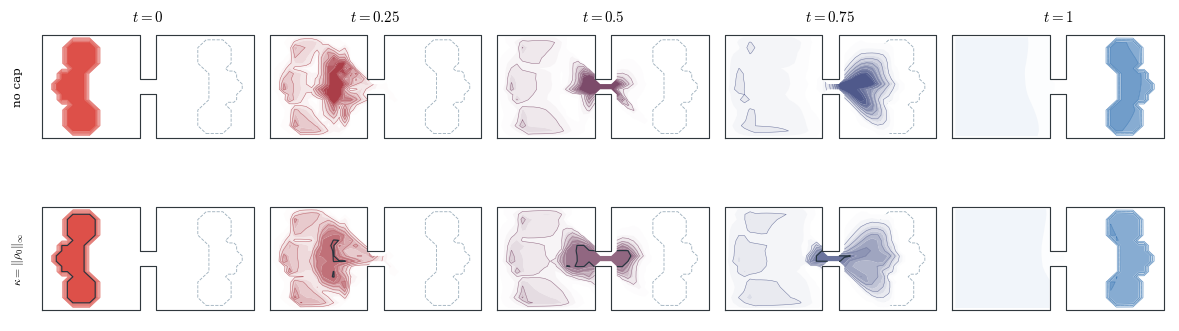

In [11]:
snapshot_indices = np.rint(np.linspace(0, grid.nt, 5)).astype(int)
vmax = 1.25 * INITIAL_PEAK
levels = vmax * np.linspace(0.0, 1.0, 13) ** 1.30
levels[0] = 0.004 * vmax

fig, axes = plt.subplots(2, 5, figsize=(12.2, 3.72), sharex=True, sharey=True)
fig.patch.set_facecolor("white")
for axis in axes.flat:
    axis.set_facecolor("white")
for row, (result, row_label) in enumerate(zip(solutions, CAP_LABELS)):
    for column, time_index in enumerate(snapshot_indices):
        time = time_index / grid.nt
        color = interp_color(time, RED, BLUE)
        draw_density(
            axes[row, column],
            result["density"][time_index],
            color,
            levels,
            result["kappa"],
        )
        if row == 0:
            axes[row, column].set_title(rf"$t={time:g}$", pad=2.0)
    axes[row, 0].text(
        -0.085,
        0.5,
        row_label,
        transform=axes[row, 0].transAxes,
        rotation=90,
        ha="center",
        va="center",
        fontsize=8.5,
    )

fig.subplots_adjust(
    left=0.07,
    right=0.998,
    top=0.91,
    bottom=0.018,
    wspace=0.025,
    hspace=0.075,
)
save_pdf(fig, OUT / "evolution.pdf", pad_inches=0.01)
fig.savefig(
    OUT / "evolution.png",
    dpi=220,
    bbox_inches="tight",
    pad_inches=0.02,
    facecolor="white",
)
fig.savefig(
    THUMB,
    dpi=100,
    bbox_inches="tight",
    pad_inches=0.02,
    facecolor="white",
)
plt.show()

## Synchronized animation

The animation linearly interpolates between consecutive optimized time slices. Because both mass conservation and the hard density bounds are convex constraints, this display interpolation preserves them up to the solver tolerance.

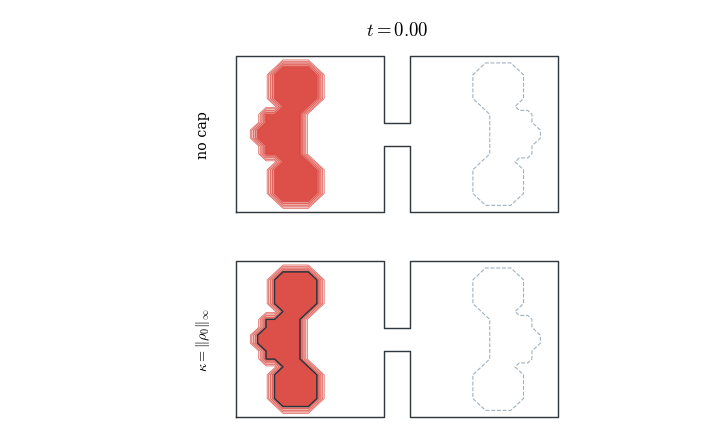

Static figure: /Users/gpeyre/Dropbox/github/ot4ml/OT4ML/figures/dynamic-variational-mfg-hard-congestion/evolution.pdf
Animation:     /Users/gpeyre/Dropbox/github/ot4ml/OT4ML/figures/dynamic-variational-mfg-hard-congestion/animation.gif
Thumbnail:     /Users/gpeyre/Dropbox/github/ot4ml/notebooks-figures/thumbnails/dynamic-variational-mfg-hard-congestion.png


In [12]:
def density_at_time(density, time):
    """Linearly interpolate a discrete density path at ``time`` in ``[0, 1]``."""
    position = np.clip(time, 0.0, 1.0) * grid.nt
    left = min(int(np.floor(position)), grid.nt - 1)
    fraction = position - left
    if position >= grid.nt:
        return density[-1]
    return (1 - fraction) * density[left] + fraction * density[left + 1]


animation_path = OUT / "animation.gif"
animation_fig, animation_axes = plt.subplots(2, 1, figsize=(5.8, 3.55))
writer = PillowWriter(fps=12)
with writer.saving(animation_fig, animation_path, dpi=125):
    for time in np.linspace(0.0, 1.0, 49):
        color = interp_color(time, RED, BLUE)
        for ax, result, row_label in zip(animation_axes, solutions, CAP_LABELS):
            ax.clear()
            density = density_at_time(result["density"], time)
            draw_density(ax, density, color, levels, result["kappa"])
            ax.text(
                -0.075,
                0.5,
                row_label,
                transform=ax.transAxes,
                rotation=90,
                ha="center",
                va="center",
                fontsize=8.2,
            )
        animation_axes[0].set_title(rf"$t={time:.2f}$", pad=2.0)
        animation_fig.subplots_adjust(
            left=0.105,
            right=0.99,
            top=0.91,
            bottom=0.02,
            hspace=0.08,
        )
        writer.grab_frame(facecolor="white")
plt.close(animation_fig)

display(Image(filename=str(animation_path)))
print(f"Static figure: {OUT / 'evolution.pdf'}")
print(f"Animation:     {animation_path}")
print(f"Thumbnail:     {THUMB}")